# Projeto 3 — Pricing Optimization com Restrições

## Objetivo

Esta etapa final transforma a curva de sensibilidade de desconto em uma **decisão automática de pricing**.

O modelo já estimou, para descontos entre 0% e 30%:

- unidades previstas;
- receita;
- lucro bruto;
- margem bruta.

Agora definimos uma função de decisão que seleciona automaticamente o melhor desconto de acordo com um objetivo de negócio, respeitando restrições comerciais e financeiras.

### Por que usar busca discreta?

O modelo de demanda vencedor foi **Random Forest**.

Como árvores de decisão produzem respostas em degraus, a relação entre desconto e demanda não é uma função contínua e suave.

Por isso, neste caso, é metodologicamente mais adequado avaliar toda a grade permitida de descontos do que utilizar um método de otimização baseado em derivadas.

A pergunta passa a ser:

> **Entre todos os descontos comercialmente permitidos, qual maximiza o objetivo escolhido sem violar a margem mínima?**


## 1. Leitura da curva de pricing gerada na fase anterior


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

ARQUIVO = "pricing_discount_sensitivity_curve.csv"

pricing = pd.read_csv(ARQUIVO)

display(pricing.head())


,category,discount_percent,forecast_units,avg_list_price,effective_price,revenue_est,cost_est,gross_profit_est,gross_margin_pct
0,Electronics,0,"1,806.96","1,284.00","1,284.00","2,320,132.99","1,508,086.45","812,046.55",35.00
1,Electronics,1,"1,806.96","1,284.00","1,271.16","2,296,931.66","1,508,086.45","788,845.22",34.34
2,Electronics,2,"1,806.96","1,284.00","1,258.32","2,273,730.33","1,508,086.45","765,643.89",33.67
3,Electronics,3,"1,800.46","1,284.00","1,245.48","2,242,441.90","1,502,667.25","739,774.65",32.99
4,Electronics,4,"1,800.46","1,284.00","1,232.64","2,219,323.94","1,502,667.25","716,656.69",32.29


## 2. Premissas da política comercial

As restrições abaixo são **premissas de decisão** e podem ser alteradas.

Nesta versão:

- desconto mínimo permitido: 0%;
- desconto máximo permitido: 30%;
- margem mínima:
  - Electronics: 25%;
  - Personal Care: 35%.

As margens mínimas são utilizadas para impedir que a busca por volume ou faturamento destrua excessivamente a rentabilidade.


In [2]:
pricing_policy = pd.DataFrame({
    "category": [
        "Electronics",
        "Personal Care"
    ],
    "min_discount": [
        0,
        0
    ],
    "max_discount": [
        30,
        30
    ],
    "min_margin_pct": [
        25,
        35
    ]
})

display(pricing_policy)


,category,min_discount,max_discount,min_margin_pct
0,Electronics,0,30,25
1,Personal Care,0,30,35


## 3. Função de otimização discreta

A função abaixo:

1. filtra os descontos permitidos;
2. elimina cenários abaixo da margem mínima;
3. maximiza a métrica escolhida;
4. retorna o ponto ótimo.

Objetivos disponíveis:

- `gross_profit_est` → lucro;
- `revenue_est` → receita;
- `forecast_units` → volume;
- `gross_margin_pct` → margem.


In [3]:
def optimize_pricing(
    pricing_curve,
    policy,
    objective
):
    results = []

    for _, rule in policy.iterrows():

        category = rule["category"]

        candidates = pricing_curve[
            (pricing_curve["category"] == category)
            & (
                pricing_curve["discount_percent"]
                >= rule["min_discount"]
            )
            & (
                pricing_curve["discount_percent"]
                <= rule["max_discount"]
            )
            & (
                pricing_curve["gross_margin_pct"]
                >= rule["min_margin_pct"]
            )
        ].copy()

        if candidates.empty:
            results.append({
                "category": category,
                "objective": objective,
                "status": "No feasible solution"
            })
            continue

        best_index = (
            candidates[objective]
            .idxmax()
        )

        best = (
            candidates
            .loc[best_index]
        )

        results.append({
            "category": category,
            "objective": objective,
            "status": "Optimal",
            "optimal_discount": best["discount_percent"],
            "forecast_units": best["forecast_units"],
            "effective_price": best["effective_price"],
            "revenue_est": best["revenue_est"],
            "gross_profit_est": best["gross_profit_est"],
            "gross_margin_pct": best["gross_margin_pct"]
        })

    return pd.DataFrame(results)


## 4. Otimização para maximizar lucro


In [4]:
optimal_profit = optimize_pricing(
    pricing_curve=pricing,
    policy=pricing_policy,
    objective="gross_profit_est"
)

display(optimal_profit)


,category,objective,status,optimal_discount,forecast_units,effective_price,revenue_est,gross_profit_est,gross_margin_pct
0,Electronics,gross_profit_est,Optimal,0,"1,806.96","1,284.00","2,320,132.99","812,046.55",35.00
1,Personal Care,gross_profit_est,Optimal,0,"2,670.50","1,670.50","4,461,078.22","2,007,485.20",45.00


### Interpretação

Se o desconto ótimo for 0%, isso não significa que descontos nunca devem ser utilizados.

Significa apenas que, **dentro da curva de demanda estimada, das premissas de custo e das restrições definidas**, nenhum desconto positivo gera lucro maior que o cenário sem desconto.


## 5. Otimização para maximizar receita


In [5]:
optimal_revenue = optimize_pricing(
    pricing_curve=pricing,
    policy=pricing_policy,
    objective="revenue_est"
)

display(optimal_revenue)


,category,objective,status,optimal_discount,forecast_units,effective_price,revenue_est,gross_profit_est,gross_margin_pct
0,Electronics,revenue_est,Optimal,13,"2,137.90","1,117.08","2,388,201.60","603,913.05",25.29
1,Personal Care,revenue_est,Optimal,0,"2,670.50","1,670.50","4,461,078.22","2,007,485.20",45.00


## 6. Otimização para maximizar volume


In [6]:
optimal_volume = optimize_pricing(
    pricing_curve=pricing,
    policy=pricing_policy,
    objective="forecast_units"
)

display(optimal_volume)


,category,objective,status,optimal_discount,forecast_units,effective_price,revenue_est,gross_profit_est,gross_margin_pct
0,Electronics,forecast_units,Optimal,13,"2,137.90","1,117.08","2,388,201.60","603,913.05",25.29
1,Personal Care,forecast_units,Optimal,14,"2,975.40","1,436.63","4,274,552.01","1,540,826.89",36.05


## 7. Comparação dos objetivos

Agora consolidamos as decisões.

Isso evidencia que a política ótima depende do que a empresa deseja maximizar.


In [7]:
decision_table = pd.concat([
    optimal_profit.assign(
        business_goal="Maximize Profit"
    ),
    optimal_revenue.assign(
        business_goal="Maximize Revenue"
    ),
    optimal_volume.assign(
        business_goal="Maximize Volume"
    )
], ignore_index=True)

display(
    decision_table[[
        "category",
        "business_goal",
        "optimal_discount",
        "forecast_units",
        "revenue_est",
        "gross_profit_est",
        "gross_margin_pct"
    ]]
)


,category,business_goal,optimal_discount,forecast_units,revenue_est,gross_profit_est,gross_margin_pct
0,Electronics,Maximize Profit,0,"1,806.96","2,320,132.99","812,046.55",35.00
1,Personal Care,Maximize Profit,0,"2,670.50","4,461,078.22","2,007,485.20",45.00
2,Electronics,Maximize Revenue,13,"2,137.90","2,388,201.60","603,913.05",25.29
3,Personal Care,Maximize Revenue,0,"2,670.50","4,461,078.22","2,007,485.20",45.00
4,Electronics,Maximize Volume,13,"2,137.90","2,388,201.60","603,913.05",25.29
5,Personal Care,Maximize Volume,14,"2,975.40","4,274,552.01","1,540,826.89",36.05


# 8. Resultado para Electronics

Com margem mínima de 25%, a categoria Electronics oferece um exemplo particularmente interessante.

A maximização de lucro e a maximização de receita levam a decisões diferentes.

Também podemos verificar o maior volume possível sem violar a margem mínima.


In [8]:
electronics_decisions = (
    decision_table[
        decision_table["category"]
        == "Electronics"
    ][[
        "business_goal",
        "optimal_discount",
        "forecast_units",
        "revenue_est",
        "gross_profit_est",
        "gross_margin_pct"
    ]]
)

display(electronics_decisions)


,business_goal,optimal_discount,forecast_units,revenue_est,gross_profit_est,gross_margin_pct
0,Maximize Profit,0,"1,806.96","2,320,132.99","812,046.55",35.00
2,Maximize Revenue,13,"2,137.90","2,388,201.60","603,913.05",25.29
4,Maximize Volume,13,"2,137.90","2,388,201.60","603,913.05",25.29


# 9. Resultado para Personal Care


In [9]:
personal_care_decisions = (
    decision_table[
        decision_table["category"]
        == "Personal Care"
    ][[
        "business_goal",
        "optimal_discount",
        "forecast_units",
        "revenue_est",
        "gross_profit_est",
        "gross_margin_pct"
    ]]
)

display(personal_care_decisions)


,business_goal,optimal_discount,forecast_units,revenue_est,gross_profit_est,gross_margin_pct
1,Maximize Profit,0,"2,670.50","4,461,078.22","2,007,485.20",45.00
3,Maximize Revenue,0,"2,670.50","4,461,078.22","2,007,485.20",45.00
5,Maximize Volume,14,"2,975.40","4,274,552.01","1,540,826.89",36.05


## 10. Fronteira viável da política comercial

Os gráficos abaixo mostram somente os pontos que respeitam a margem mínima.

O ponto ótimo de lucro é destacado visualmente.


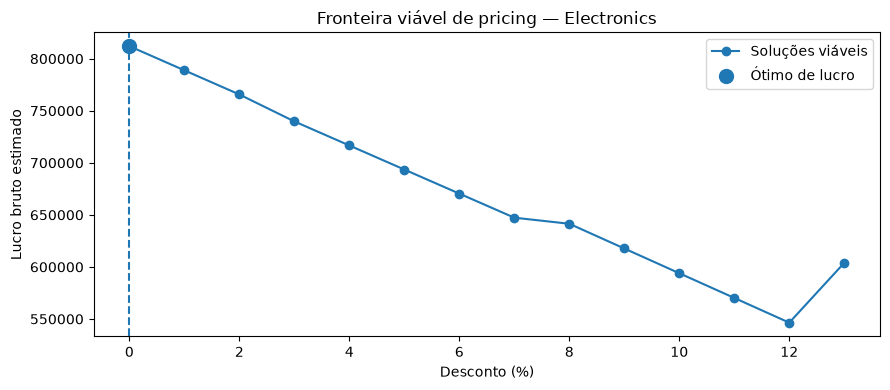

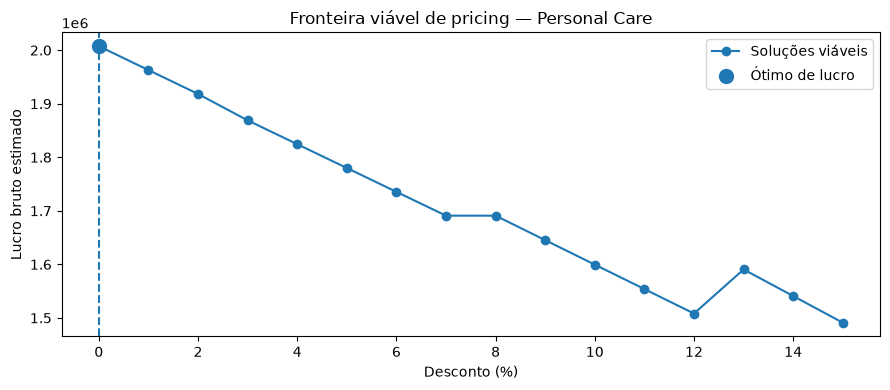

In [10]:
for _, rule in pricing_policy.iterrows():

    categoria = rule["category"]

    feasible = pricing[
        (pricing["category"] == categoria)
        & (
            pricing["discount_percent"]
            >= rule["min_discount"]
        )
        & (
            pricing["discount_percent"]
            <= rule["max_discount"]
        )
        & (
            pricing["gross_margin_pct"]
            >= rule["min_margin_pct"]
        )
    ].copy()

    best = optimal_profit[
        optimal_profit["category"]
        == categoria
    ].iloc[0]

    plt.figure(figsize=(9, 4))

    plt.plot(
        feasible["discount_percent"],
        feasible["gross_profit_est"],
        marker="o",
        label="Soluções viáveis"
    )

    plt.scatter(
        best["optimal_discount"],
        best["gross_profit_est"],
        s=100,
        label="Ótimo de lucro"
    )

    plt.axvline(
        best["optimal_discount"],
        linestyle="--"
    )

    plt.title(
        f"Fronteira viável de pricing — {categoria}"
    )

    plt.xlabel("Desconto (%)")
    plt.ylabel("Lucro bruto estimado")
    plt.legend()
    plt.tight_layout()
    plt.show()


# 11. Sensibilidade à margem mínima

Uma política de pricing não precisa ter uma única margem mínima.

Vamos testar diferentes limites para entender quanto a restrição financeira altera a decisão de desconto.

### Electronics
- 20%
- 25%
- 30%

### Personal Care
- 25%
- 30%
- 35%

O objetivo desta análise será **maximizar volume**.

Esse caso é interessante porque evidencia o trade-off entre crescimento de vendas e proteção de margem.


In [11]:
margin_sensitivity_rows = []

margin_scenarios = {
    "Electronics": [
        20,
        25,
        30
    ],
    "Personal Care": [
        25,
        30,
        35
    ]
}

for category, margins in margin_scenarios.items():

    for min_margin in margins:

        temp_policy = pd.DataFrame({
            "category": [category],
            "min_discount": [0],
            "max_discount": [30],
            "min_margin_pct": [min_margin]
        })

        solution = optimize_pricing(
            pricing_curve=pricing,
            policy=temp_policy,
            objective="forecast_units"
        )

        row = solution.iloc[0]

        margin_sensitivity_rows.append({
            "category": category,
            "min_margin_requirement": min_margin,
            "optimal_discount_for_volume": (
                row["optimal_discount"]
            ),
            "forecast_units": (
                row["forecast_units"]
            ),
            "revenue_est": (
                row["revenue_est"]
            ),
            "gross_profit_est": (
                row["gross_profit_est"]
            ),
            "resulting_margin_pct": (
                row["gross_margin_pct"]
            )
        })


margin_sensitivity = pd.DataFrame(
    margin_sensitivity_rows
)

display(margin_sensitivity)


,category,min_margin_requirement,optimal_discount_for_volume,forecast_units,revenue_est,gross_profit_est,resulting_margin_pct
0,Electronics,20,18,"2,225.57","2,343,258.33","485,797.46",20.73
1,Electronics,25,13,"2,137.90","2,388,201.60","603,913.05",25.29
2,Electronics,30,0,"1,806.96","2,320,132.99","812,046.55",35.00
3,Personal Care,25,26,"3,136.20","3,876,882.42","995,415.76",25.68
4,Personal Care,30,19,"3,063.43","4,145,138.70","1,330,538.35",32.10
5,Personal Care,35,14,"2,975.40","4,274,552.01","1,540,826.89",36.05


## 12. Visual — margem mínima × desconto permitido


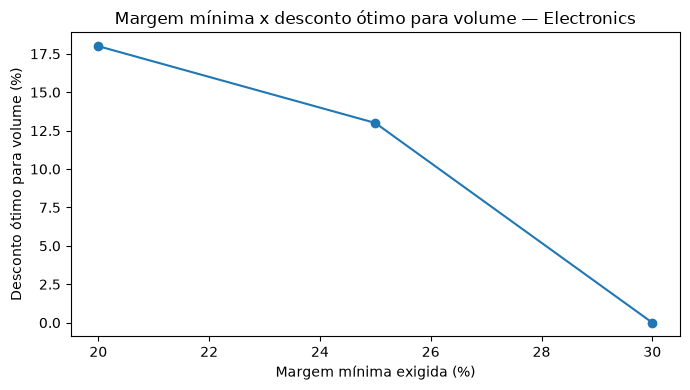

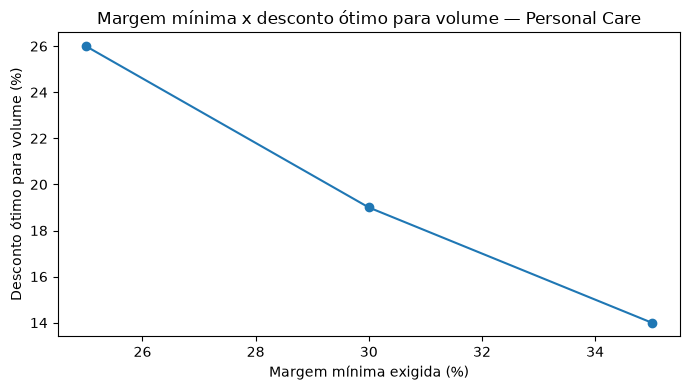

In [12]:
for categoria in margin_sensitivity["category"].unique():

    temp = margin_sensitivity[
        margin_sensitivity["category"]
        == categoria
    ].copy()

    plt.figure(figsize=(7, 4))

    plt.plot(
        temp["min_margin_requirement"],
        temp["optimal_discount_for_volume"],
        marker="o"
    )

    plt.title(
        f"Margem mínima x desconto ótimo para volume — {categoria}"
    )

    plt.xlabel(
        "Margem mínima exigida (%)"
    )

    plt.ylabel(
        "Desconto ótimo para volume (%)"
    )

    plt.tight_layout()
    plt.show()


# 13. Política recomendada

O projeto permite separar três estratégias:

### Estratégia orientada a lucro
Seleciona o desconto que gera maior lucro bruto.

### Estratégia orientada a receita
Seleciona o desconto que maximiza faturamento, desde que a margem mínima seja respeitada.

### Estratégia orientada a volume
Seleciona o maior volume permitido pela política de margem.

Essa separação é importante porque **não existe um único “preço ótimo” independente do objetivo de negócio**.


In [13]:
recommended_policy = (
    decision_table[
        decision_table["business_goal"]
        == "Maximize Profit"
    ][[
        "category",
        "optimal_discount",
        "forecast_units",
        "effective_price",
        "revenue_est",
        "gross_profit_est",
        "gross_margin_pct"
    ]]
    .copy()
)

recommended_policy["recommendation"] = (
    "Profit-oriented pricing"
)

display(recommended_policy)


,category,optimal_discount,forecast_units,effective_price,revenue_est,gross_profit_est,gross_margin_pct,recommendation
0,Electronics,0,"1,806.96","1,284.00","2,320,132.99","812,046.55",35.00,Profit-oriented pricing
1,Personal Care,0,"2,670.50","1,670.50","4,461,078.22","2,007,485.20",45.00,Profit-oriented pricing


# 14. Conclusão do Projeto 3

O Projeto 3 fecha a sequência iniciada no forecast.

### Projeto 1
**Quanto esperamos vender?**

Forecast de demanda, fatores comerciais, cenários e planejamento financeiro.

### Projeto 2
**Quanto devemos comprar?**

Otimização de estoque e alocação de capital com Solver.

### Projeto 3
**Quanto devemos cobrar?**

Pricing e otimização de margem com restrições financeiras.

---

A principal conclusão desta etapa é:

> **O preço ótimo depende do objetivo empresarial e das restrições de margem. Maximizar volume, receita e lucro pode levar a decisões de desconto diferentes.**

Nos dados modelados:

- Electronics pode aumentar faturamento e volume com desconto, mas o lucro máximo permanece no cenário sem desconto;
- Personal Care apresenta resposta de volume a descontos, porém receita e lucro continuam maiores sem desconto;
- restrições mínimas de margem limitam automaticamente os níveis de desconto que podem ser considerados comercialmente viáveis.

Portanto, o projeto demonstra uma abordagem de pricing orientada não apenas a vendas, mas a **rentabilidade e decisão financeira**.


## 15. Exportação


In [14]:
decision_table.to_csv(
    "pricing_optimization_decisions.csv",
    index=False,
    encoding="utf-8-sig"
)

margin_sensitivity.to_csv(
    "pricing_margin_constraint_sensitivity.csv",
    index=False,
    encoding="utf-8-sig"
)

recommended_policy.to_csv(
    "pricing_recommended_policy.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Arquivos gerados:")
print("- pricing_optimization_decisions.csv")
print("- pricing_margin_constraint_sensitivity.csv")
print("- pricing_recommended_policy.csv")


Arquivos gerados:
- pricing_optimization_decisions.csv
- pricing_margin_constraint_sensitivity.csv
- pricing_recommended_policy.csv
